In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1- Chargement et exploration du dataset

In [3]:
data = pd.read_csv('churn_data.csv')
data.head(10)

,user,churn,age,housing,credit_score,deposits,withdrawal,purchases_partners,purchases,cc_taken,...,waiting_4_loan,cancelled_loan,received_loan,rejected_loan,zodiac_sign,left_for_two_month_plus,left_for_one_month,rewards_earned,reward_rate,is_referred
0,55409,0,37.0,na,NaN,0,0,0,0,0,...,0,0,0,0,Leo,1,0,NaN,0.00,0
1,23547,0,28.0,R,486.0,0,0,1,0,0,...,0,0,0,0,Leo,0,0,44.0,1.47,1
2,58313,0,35.0,R,561.0,47,2,86,47,0,...,0,0,0,0,Capricorn,1,0,65.0,2.17,0
3,8095,0,26.0,R,567.0,26,3,38,25,0,...,0,0,0,0,Capricorn,0,0,33.0,1.10,1
4,61353,1,27.0,na,NaN,0,0,2,0,0,...,0,0,0,0,Aries,1,0,1.0,0.03,0
5,3120,1,32.0,R,567.0,5,3,111,5,0,...,0,0,0,0,Taurus,0,0,55.0,1.83,0
6,41406,0,21.0,na,475.0,0,0,4,0,0,...,0,0,0,0,Cancer,0,0,2.0,0.07,0
7,67679,0,24.0,na,NaN,0,0,2,0,0,...,0,0,0,0,Leo,0,0,1.0,0.11,0
8,21269,0,28.0,R,548.0,0,0,0,0,2,...,0,0,0,0,Sagittarius,0,0,26.0,0.87,1
9,25788,0,23.0,na,658.0,1,0,87,1,0,...,0,0,0,0,Aquarius,0,0,32.0,1.07,0


In [4]:
data.shape

(27000, 31)

In [5]:
data.dtypes

user                         int64
churn                        int64
age                        float64
housing                        str
credit_score               float64
deposits                     int64
withdrawal                   int64
purchases_partners           int64
purchases                    int64
cc_taken                     int64
cc_recommended               int64
cc_disliked                  int64
cc_liked                     int64
cc_application_begin         int64
app_downloaded               int64
web_user                     int64
app_web_user                 int64
ios_user                     int64
android_user                 int64
registered_phones            int64
payment_type                   str
waiting_4_loan               int64
cancelled_loan               int64
received_loan                int64
rejected_loan                int64
zodiac_sign                    str
left_for_two_month_plus      int64
left_for_one_month           int64
rewards_earned      

In [6]:
data.describe()

,user,churn,age,credit_score,deposits,withdrawal,purchases_partners,purchases,cc_taken,cc_recommended,...,registered_phones,waiting_4_loan,cancelled_loan,received_loan,rejected_loan,left_for_two_month_plus,left_for_one_month,rewards_earned,reward_rate,is_referred
count,27000.000000,27000.000000,26996.000000,18969.000000,27000.000000,27000.000000,27000.000000,27000.000000,27000.000000,27000.000000,...,27000.000000,27000.000000,27000.000000,27000.000000,27000.000000,27000.000000,27000.000000,23773.000000,27000.000000,27000.000000
mean,35422.702519,0.413852,32.219921,542.944225,3.341556,0.307000,28.062519,3.273481,0.073778,92.625778,...,0.420926,0.001296,0.018815,0.018185,0.004889,0.173444,0.018074,29.110125,0.907684,0.318037
std,20321.006678,0.492532,9.964838,61.059315,9.131406,1.055416,42.219686,8.953077,0.437299,88.869343,...,0.912831,0.035981,0.135873,0.133623,0.069751,0.378638,0.133222,21.973478,0.752016,0.465723
min,1.000000,0.000000,17.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,17810.500000,0.000000,25.000000,507.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.200000,0.000000
50%,35749.000000,0.000000,30.000000,542.000000,0.000000,0.000000,9.000000,0.000000,0.000000,65.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,25.000000,0.780000,0.000000
75%,53244.250000,1.000000,37.000000,578.000000,1.000000,0.000000,43.000000,1.000000,0.000000,164.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,48.000000,1.530000,1.000000
max,69658.000000,1.000000,91.000000,838.000000,65.000000,29.000000,1067.000000,63.000000,29.000000,522.000000,...,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,114.000000,4.000000,1.000000


In [7]:
#identification des donnees manquantes
data.isnull().sum()

user                          0
churn                         0
age                           4
housing                       0
credit_score               8031
deposits                      0
withdrawal                    0
purchases_partners            0
purchases                     0
cc_taken                      0
cc_recommended                0
cc_disliked                   0
cc_liked                      0
cc_application_begin          0
app_downloaded                0
web_user                      0
app_web_user                  0
ios_user                      0
android_user                  0
registered_phones             0
payment_type                  0
waiting_4_loan                0
cancelled_loan                0
received_loan                 0
rejected_loan                 0
zodiac_sign                   0
left_for_two_month_plus       0
left_for_one_month            0
rewards_earned             3227
reward_rate                   0
is_referred                   0
dtype: i

In [8]:
#detection des doublons
duplicates = data.duplicated()
duplicates.value_counts()


False    26542
True       458
Name: count, dtype: int64

In [9]:
#Suppression des doublons
data.drop_duplicates(inplace=True)
data.shape

(26542, 31)

## 2- Preprocessing

<Axes: >

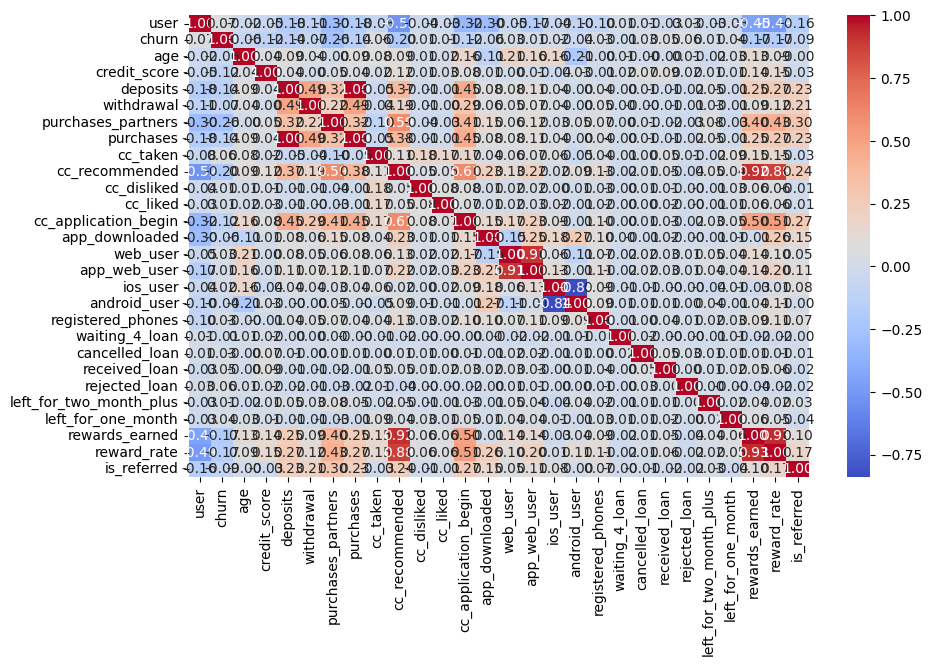

In [10]:
#correlation
plt.figure(figsize=(10, 6))
sns.heatmap(data.select_dtypes(include=['number']).corr(), annot=True, fmt='.2f', cmap='coolwarm')

In [11]:
#suppression colonnes qui ne servent a rien
data.drop(['user', 'zodiac_sign'], axis=1, inplace=True)
data.shape

(26542, 29)

In [12]:
#remplacement des 'na' (chaine) par NaN
data['housing']      = data['housing'].replace('na', np.nan)
data['payment_type'] = data['payment_type'].replace('na', np.nan)

In [13]:
#Traitement des donnees manquantes
#remplacer les valeurs manquantes par la mediane
data['credit_score'].fillna(data['credit_score'].median(), inplace=True)
data['rewards_earned'].fillna(data['rewards_earned'].median(), inplace=True)
data['age'].fillna(data['age'].median(), inplace=True)

C:\Users\Lowe\AppData\Local\Temp\ipykernel_22104\2849350921.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['credit_score'].fillna(data['credit_score'].median(), inplace=True)
C:\Users\Lowe\AppData\Local\Temp\ipykernel_22104\2849350921.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series thro

0        37.0
1        28.0
2        35.0
3        26.0
4        27.0
         ... 
26995    24.0
26996    26.0
26997    22.0
26998    46.0
26999    34.0
Name: age, Length: 26542, dtype: float64

In [14]:
#traitement des donnees manquantes
#remplacer les valeurs manquantes de housing et payment_type par le mode
data['housing'].fillna(data['housing'].mode()[0], inplace=True)
data['payment_type'].fillna(data['payment_type'].mode()[0], inplace=True)


C:\Users\Lowe\AppData\Local\Temp\ipykernel_22104\4022978984.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['housing'].fillna(data['housing'].mode()[0], inplace=True)
C:\Users\Lowe\AppData\Local\Temp\ipykernel_22104\4022978984.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chain

0           Bi-Weekly
1              Weekly
2        Semi-Monthly
3           Bi-Weekly
4           Bi-Weekly
             ...     
26995          Weekly
26996       Bi-Weekly
26997       Bi-Weekly
26998    Semi-Monthly
26999       Bi-Weekly
Name: payment_type, Length: 26542, dtype: str

In [15]:
#verification des valeurs manquantes apres traitement
data.isnull().sum()

churn                          0
age                            4
housing                    13606
credit_score                7789
deposits                       0
withdrawal                     0
purchases_partners             0
purchases                      0
cc_taken                       0
cc_recommended                 0
cc_disliked                    0
cc_liked                       0
cc_application_begin           0
app_downloaded                 0
web_user                       0
app_web_user                   0
ios_user                       0
android_user                   0
registered_phones              0
payment_type                3835
waiting_4_loan                 0
cancelled_loan                 0
received_loan                  0
rejected_loan                  0
left_for_two_month_plus        0
left_for_one_month             0
rewards_earned              3163
reward_rate                    0
is_referred                    0
dtype: int64

In [16]:
#bon apres avoir essayer de remplacer par fillna , les valeurs manquantes nont pas disparu, donc on va essayer une autre technique d'imputation,
#on va utiliser la classe SimpleImputer de sklearn pour remplacer les valeurs manquantes par la mediane pour les colonnes numeriques et par le mode pour les colonnes categorique
#imputation
from sklearn.impute import SimpleImputer

# valeurs numeriques

num_cols = ['age', 'credit_score', 'rewards_earned', 'reward_rate']
imp_num = SimpleImputer(strategy='median')
data[num_cols] = imp_num.fit_transform(data[num_cols])

#valeurs categoriques 
cat_cols = ['housing', 'payment_type']
imp_cat = SimpleImputer(strategy='most_frequent')
data[cat_cols] = imp_cat.fit_transform(data[cat_cols])


In [17]:
#verification des valeurs manquantes apres traitement
data.isnull().sum() 

churn                      0
age                        0
housing                    0
credit_score               0
deposits                   0
withdrawal                 0
purchases_partners         0
purchases                  0
cc_taken                   0
cc_recommended             0
cc_disliked                0
cc_liked                   0
cc_application_begin       0
app_downloaded             0
web_user                   0
app_web_user               0
ios_user                   0
android_user               0
registered_phones          0
payment_type               0
waiting_4_loan             0
cancelled_loan             0
received_loan              0
rejected_loan              0
left_for_two_month_plus    0
left_for_one_month         0
rewards_earned             0
reward_rate                0
is_referred                0
dtype: int64

In [18]:
#ici on va changer la valeur de age float en int
data['age'] = data['age'].astype(int)
data.dtypes

churn                        int64
age                          int64
housing                        str
credit_score               float64
deposits                     int64
withdrawal                   int64
purchases_partners           int64
purchases                    int64
cc_taken                     int64
cc_recommended               int64
cc_disliked                  int64
cc_liked                     int64
cc_application_begin         int64
app_downloaded               int64
web_user                     int64
app_web_user                 int64
ios_user                     int64
android_user                 int64
registered_phones            int64
payment_type                   str
waiting_4_loan               int64
cancelled_loan               int64
received_loan                int64
rejected_loan                int64
left_for_two_month_plus      int64
left_for_one_month           int64
rewards_earned             float64
reward_rate                float64
is_referred         

In [19]:
#remplacement de rewards_earned par la mediane
data['rewards_earned'].fillna(data['rewards_earned'].median(), inplace=True)

C:\Users\Lowe\AppData\Local\Temp\ipykernel_22104\2049317819.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['rewards_earned'].fillna(data['rewards_earned'].median(), inplace=True)


0        25.0
1        44.0
2        65.0
3        33.0
4         1.0
         ... 
26995    32.0
26996     2.0
26997    28.0
26998    27.0
26999     4.0
Name: rewards_earned, Length: 26542, dtype: float64

## 3 - Exploratory Data Alanysis( EDA )

C:\Users\Lowe\AppData\Local\Temp\ipykernel_22104\2984373638.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=data, palette='muted')


<Axes: xlabel='churn', ylabel='count'>

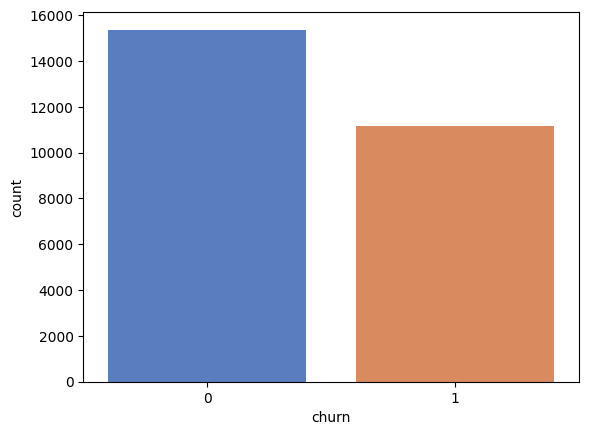

In [20]:
#distribution de la cible
sns.countplot(x='churn', data=data, palette='muted')

C:\Users\Lowe\AppData\Local\Temp\ipykernel_22104\3807985390.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='credit_score', data=data, palette='muted')


<Axes: xlabel='churn', ylabel='credit_score'>

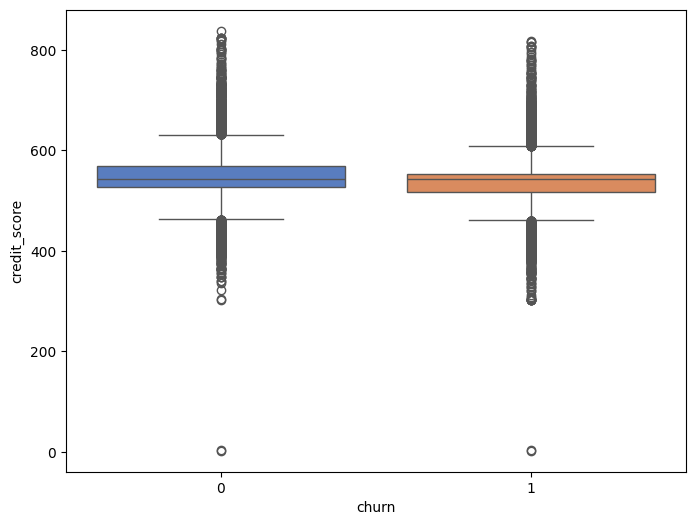

In [21]:
#faisons un boxplot pour voir la distribution de credit_score en fonction de churn
plt.figure(figsize=(8, 6))
sns.boxplot(x='churn', y='credit_score', data=data, palette='muted')

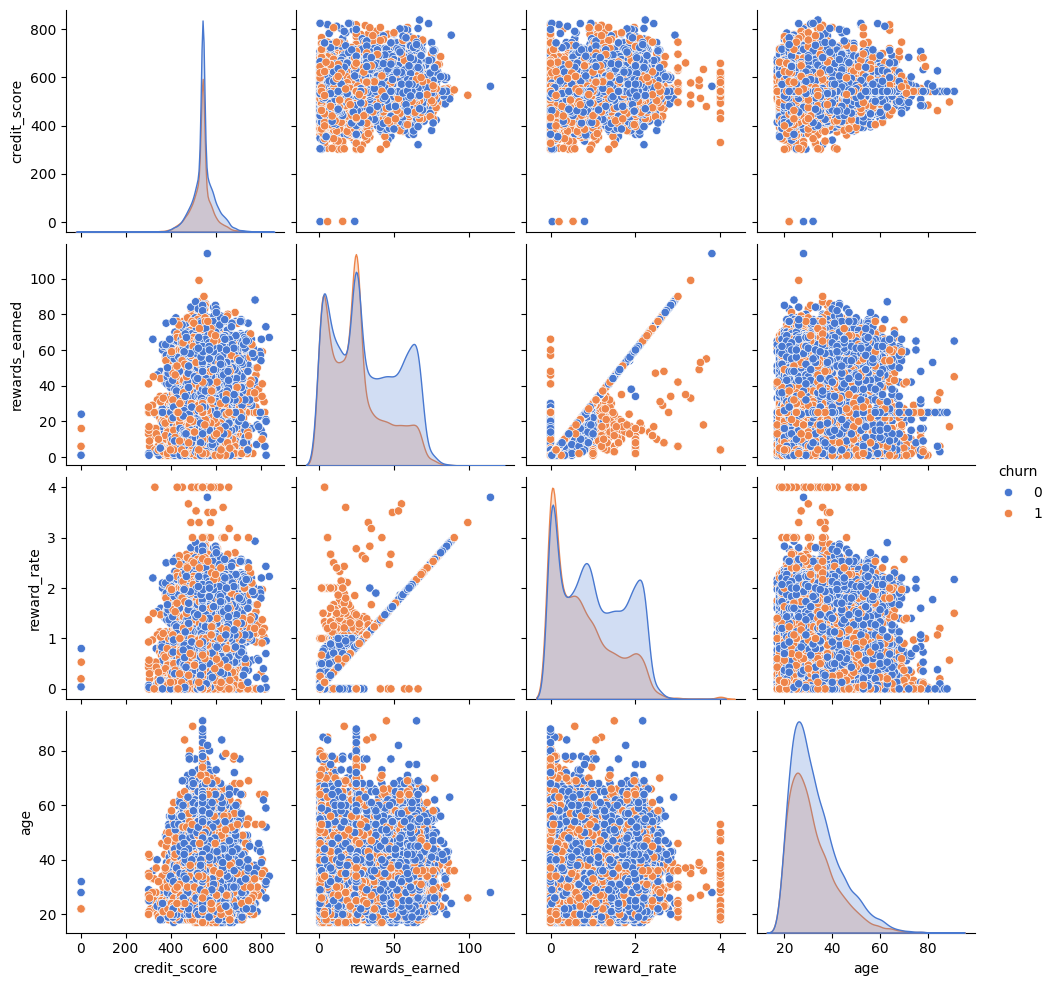

In [22]:
#les variables importantes pour la prediction de churn sont credit_score, rewards_earned, reward_rate, age, housing et payment_type
#faisons un pairplot pour voir les relations entre ces variables et la cible
sns.pairplot(data, hue='churn', vars=['credit_score', 'rewards_earned', 'reward_rate', 'age'], palette='muted')

In [23]:
#traitement des outliers
def replace_outliers(df):
    for col in df.select_dtypes(include=['number']).columns:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lb, ub = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        df[col] = np.where(df[col] < lb, lb, df[col])
        df[col] = np.where(df[col] > ub, ub, df[col])

replace_outliers(data)

C:\Users\Lowe\AppData\Local\Temp\ipykernel_22104\1982264831.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='credit_score', data=data, palette='muted')


<Axes: xlabel='churn', ylabel='credit_score'>

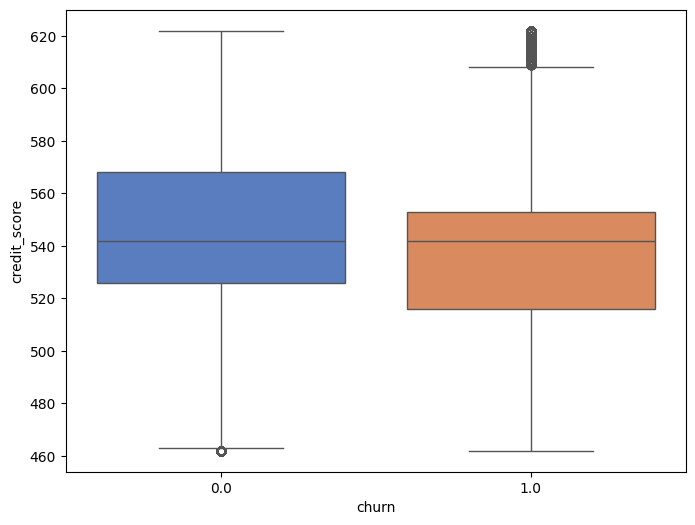

In [24]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='churn', y='credit_score', data=data, palette='muted')

In [25]:
#passons a l'encodage avec label encoder pour les variables categorique
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['housing'] = le.fit_transform(data['housing'])
data.head() 



,churn,age,housing,credit_score,deposits,withdrawal,purchases_partners,purchases,cc_taken,cc_recommended,...,payment_type,waiting_4_loan,cancelled_loan,received_loan,rejected_loan,left_for_two_month_plus,left_for_one_month,rewards_earned,reward_rate,is_referred
0,0.0,37.0,1,542.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Bi-Weekly,0.0,0.0,0.0,0.0,0.0,0.0,25.0,0.00,0.0
1,0.0,28.0,1,486.0,0.0,0.0,1.0,0.0,0.0,96.0,...,Weekly,0.0,0.0,0.0,0.0,0.0,0.0,44.0,1.47,1.0
2,0.0,35.0,1,561.0,2.5,0.0,86.0,2.5,0.0,285.0,...,Semi-Monthly,0.0,0.0,0.0,0.0,0.0,0.0,65.0,2.17,0.0
3,0.0,26.0,1,567.0,2.5,0.0,38.0,2.5,0.0,74.0,...,Bi-Weekly,0.0,0.0,0.0,0.0,0.0,0.0,33.0,1.10,1.0
4,1.0,27.0,1,542.0,0.0,0.0,2.0,0.0,0.0,0.0,...,Bi-Weekly,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.03,0.0


In [26]:
#encodage de la variable payment_type avec frequency encoding
payment_freq = data['payment_type'].value_counts() / len(data)
data['payment_type'] = data['payment_type'].map(payment_freq)
data.head()


,churn,age,housing,credit_score,deposits,withdrawal,purchases_partners,purchases,cc_taken,cc_recommended,...,payment_type,waiting_4_loan,cancelled_loan,received_loan,rejected_loan,left_for_two_month_plus,left_for_one_month,rewards_earned,reward_rate,is_referred
0,0.0,37.0,1,542.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.615553,0.0,0.0,0.0,0.0,0.0,0.0,25.0,0.00,0.0
1,0.0,28.0,1,486.0,0.0,0.0,1.0,0.0,0.0,96.0,...,0.196293,0.0,0.0,0.0,0.0,0.0,0.0,44.0,1.47,1.0
2,0.0,35.0,1,561.0,2.5,0.0,86.0,2.5,0.0,285.0,...,0.090008,0.0,0.0,0.0,0.0,0.0,0.0,65.0,2.17,0.0
3,0.0,26.0,1,567.0,2.5,0.0,38.0,2.5,0.0,74.0,...,0.615553,0.0,0.0,0.0,0.0,0.0,0.0,33.0,1.10,1.0
4,1.0,27.0,1,542.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.615553,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.03,0.0


In [27]:
#suppression de payment_type cat il ya deja l'encodage de payment_type
data.drop('payment_type', axis=1, inplace=True)
data.shape

(26542, 28)

In [28]:
#separation X et y
X = data.drop(['churn'], axis=1)
y = data['churn']

In [29]:
#train / test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [30]:
#normalisation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 4- Modele de classification

### a- Logistic Regression

In [31]:
#regression logistique
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

c:\Users\Lowe\Documents\Venv\Python_bases\Cours_python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

<Axes: >

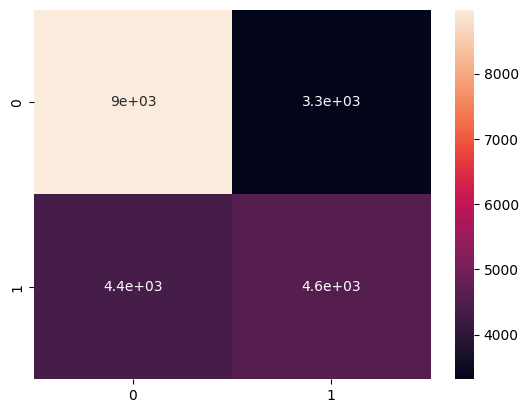

In [32]:
#evaluation du modele
y_predict_train = classifier.predict(X_train)
from sklearn.metrics import classification_report, confusion_matrix
cmt = confusion_matrix(y_train, y_predict_train)
sns.heatmap(cmt, annot=True)

In [33]:
print(classification_report(y_train, y_predict_train))  

              precision    recall  f1-score   support

         0.0       0.67      0.73      0.70     12294
         1.0       0.58      0.51      0.54      8939

    accuracy                           0.64     21233
   macro avg       0.63      0.62      0.62     21233
weighted avg       0.63      0.64      0.63     21233



### b-Decision tree

In [34]:

from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'entropy')
classifier.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

<Axes: >

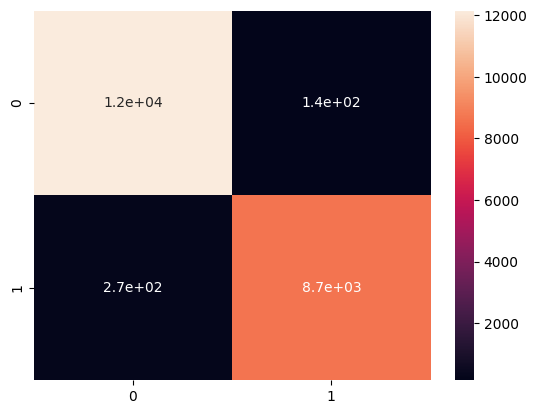

In [35]:
#evaluation du modele
y_predict_train = classifier.predict(X_train)
from sklearn.metrics import classification_report, confusion_matrix
cmt = confusion_matrix(y_train, y_predict_train)
sns.heatmap(cmt, annot=True)

In [36]:
print(classification_report(y_train, y_predict_train))  

              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98     12294
         1.0       0.98      0.97      0.98      8939

    accuracy                           0.98     21233
   macro avg       0.98      0.98      0.98     21233
weighted avg       0.98      0.98      0.98     21233



### c-Random Forest

In [37]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier()
classifier.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

<Axes: >

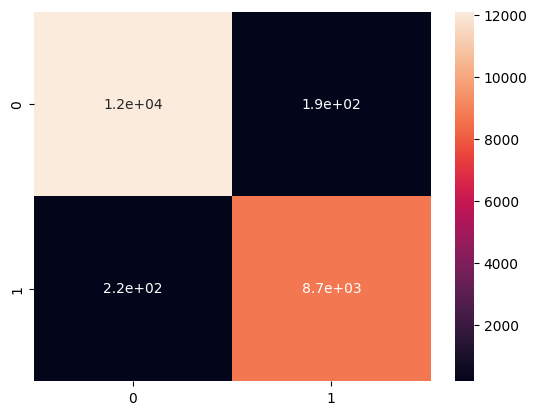

In [38]:
y_predict_train = classifier.predict(X_train)
from sklearn.metrics import classification_report, confusion_matrix
cmt = confusion_matrix(y_train, y_predict_train)
sns.heatmap(cmt, annot=True)

In [39]:
print(classification_report(y_train, y_predict_train))  

              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98     12294
         1.0       0.98      0.98      0.98      8939

    accuracy                           0.98     21233
   macro avg       0.98      0.98      0.98     21233
weighted avg       0.98      0.98      0.98     21233



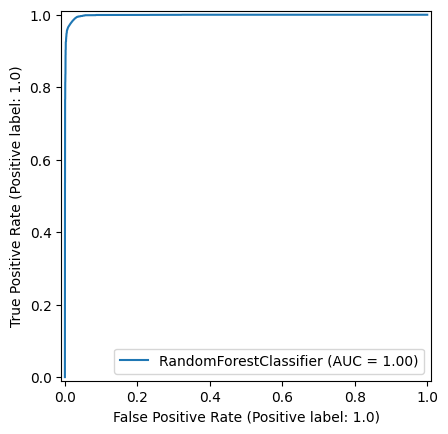

In [40]:
#courbe ROC
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(classifier, X_train, y_train)

### d-SVM

In [41]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'linear', random_state = 0)
classifier.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


<Axes: >

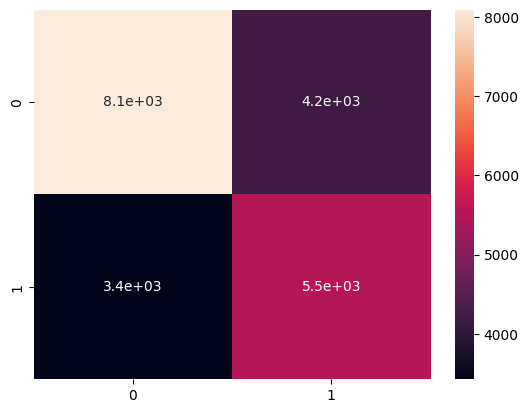

In [42]:
y_predict_train = classifier.predict(X_train)
from sklearn.metrics import classification_report, confusion_matrix
cmt = confusion_matrix(y_train, y_predict_train)
sns.heatmap(cmt, annot=True)

In [43]:
print(classification_report(y_train, y_predict_train))  

              precision    recall  f1-score   support

         0.0       0.70      0.66      0.68     12294
         1.0       0.57      0.62      0.59      8939

    accuracy                           0.64     21233
   macro avg       0.64      0.64      0.64     21233
weighted avg       0.65      0.64      0.64     21233



In [ ]:
print(classification_report(y_train, y_predict_train)) 

### e-XGBOOST

In [ ]:
import xgboost as xgb
D_train = xgb.DMatrix(X_train, label=y_train)
D_test = xgb.DMatrix(X_test, label=y_test)

In [ ]:

#cross validation

from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator=classifier,X=X_train, y=y_train, cv=10)
print("cross val accuracies", (accuracies))

In [ ]:
#grid search cv
from sklearn.model_selection import GridSearchCV
parameters = { 'n_estimators': [150,200,250,300,350],'max_depth':[10,15,20,25,30]}

clf = GridSearchCV(estimator= classifier, param_grid=parameters,n_jobs=-1,cv=10)

clf.fit(X_train,y_train)

In [ ]:
y_predict_train = classifier.predict(X_train)
from sklearn.metrics import classification_report, confusion_matrix
cmt = confusion_matrix(y_train, y_predict_train)
sns.heatmap(cmt, annot=True)

In [ ]:
print(classification_report(y_train, y_predict_train))  

In [ ]:
#bon normalement apres avoir fair l'optimisation du random, je devais prendre les meilleurs parametres 
#pour optimiser les autres mais il n'y a plus le temps. 
# c'est juste pour expliquer mon raisonnement.

In [ ]:
#sauvegarde du meilleur model
import pickle
pickle.dump(classifier, open('model.pkl', 'wb'))